In [1]:
from tqdm.auto import tqdm
import pandas as pd
from transformers import AutoTokenizer
import importlib
importlib.reload(importlib.import_module("src.feature_labelling.token_labels"))
importlib.reload(importlib.import_module("src.feature_labelling.feature_pmi"))
from src.feature_labelling.token_labels import build_token_label_dataframe
from src.feature_labelling.feature_pmi import *
import numpy as np


/home/celian/miniconda3/envs/joker/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd

path_prefix = "/work03/celian/code_feature_labelling/output/gemma-2-2b/gemma-scope-2b-pt-res-canonical_layer_width_16kcanonical"
concepts = ["ast_labels", "design_patterns"]#, "idioms_and_structures"]#, "joern_annotations"]


dict_df_tcf = {}
dict_df_ast_purity = {}
ast_purity_done = False
for concept in concepts:
    dict_df_tcf[concept] = {}
    for layer in tqdm(range(26), desc=f"Loading {concept} dataframes"):
        dict_df_tcf[concept][layer] = pd.read_parquet(f"{path_prefix}/{concept}/tcf_layer_{layer}.parquet")
        if ast_purity_done is False:
            dict_df_ast_purity[layer] = pd.read_parquet(f"{path_prefix}/ast_purity/ast_purity_layer_{layer}.parquet")
    ast_purity_done = True

Loading design_patterns dataframes: 100%|██████████| 26/26 [00:00<00:00, 122.48it/s]


Computing TCF-AUC scores for design_patterns: 100%|██████████| 26/26 [00:00<00:00, 196.76it/s]


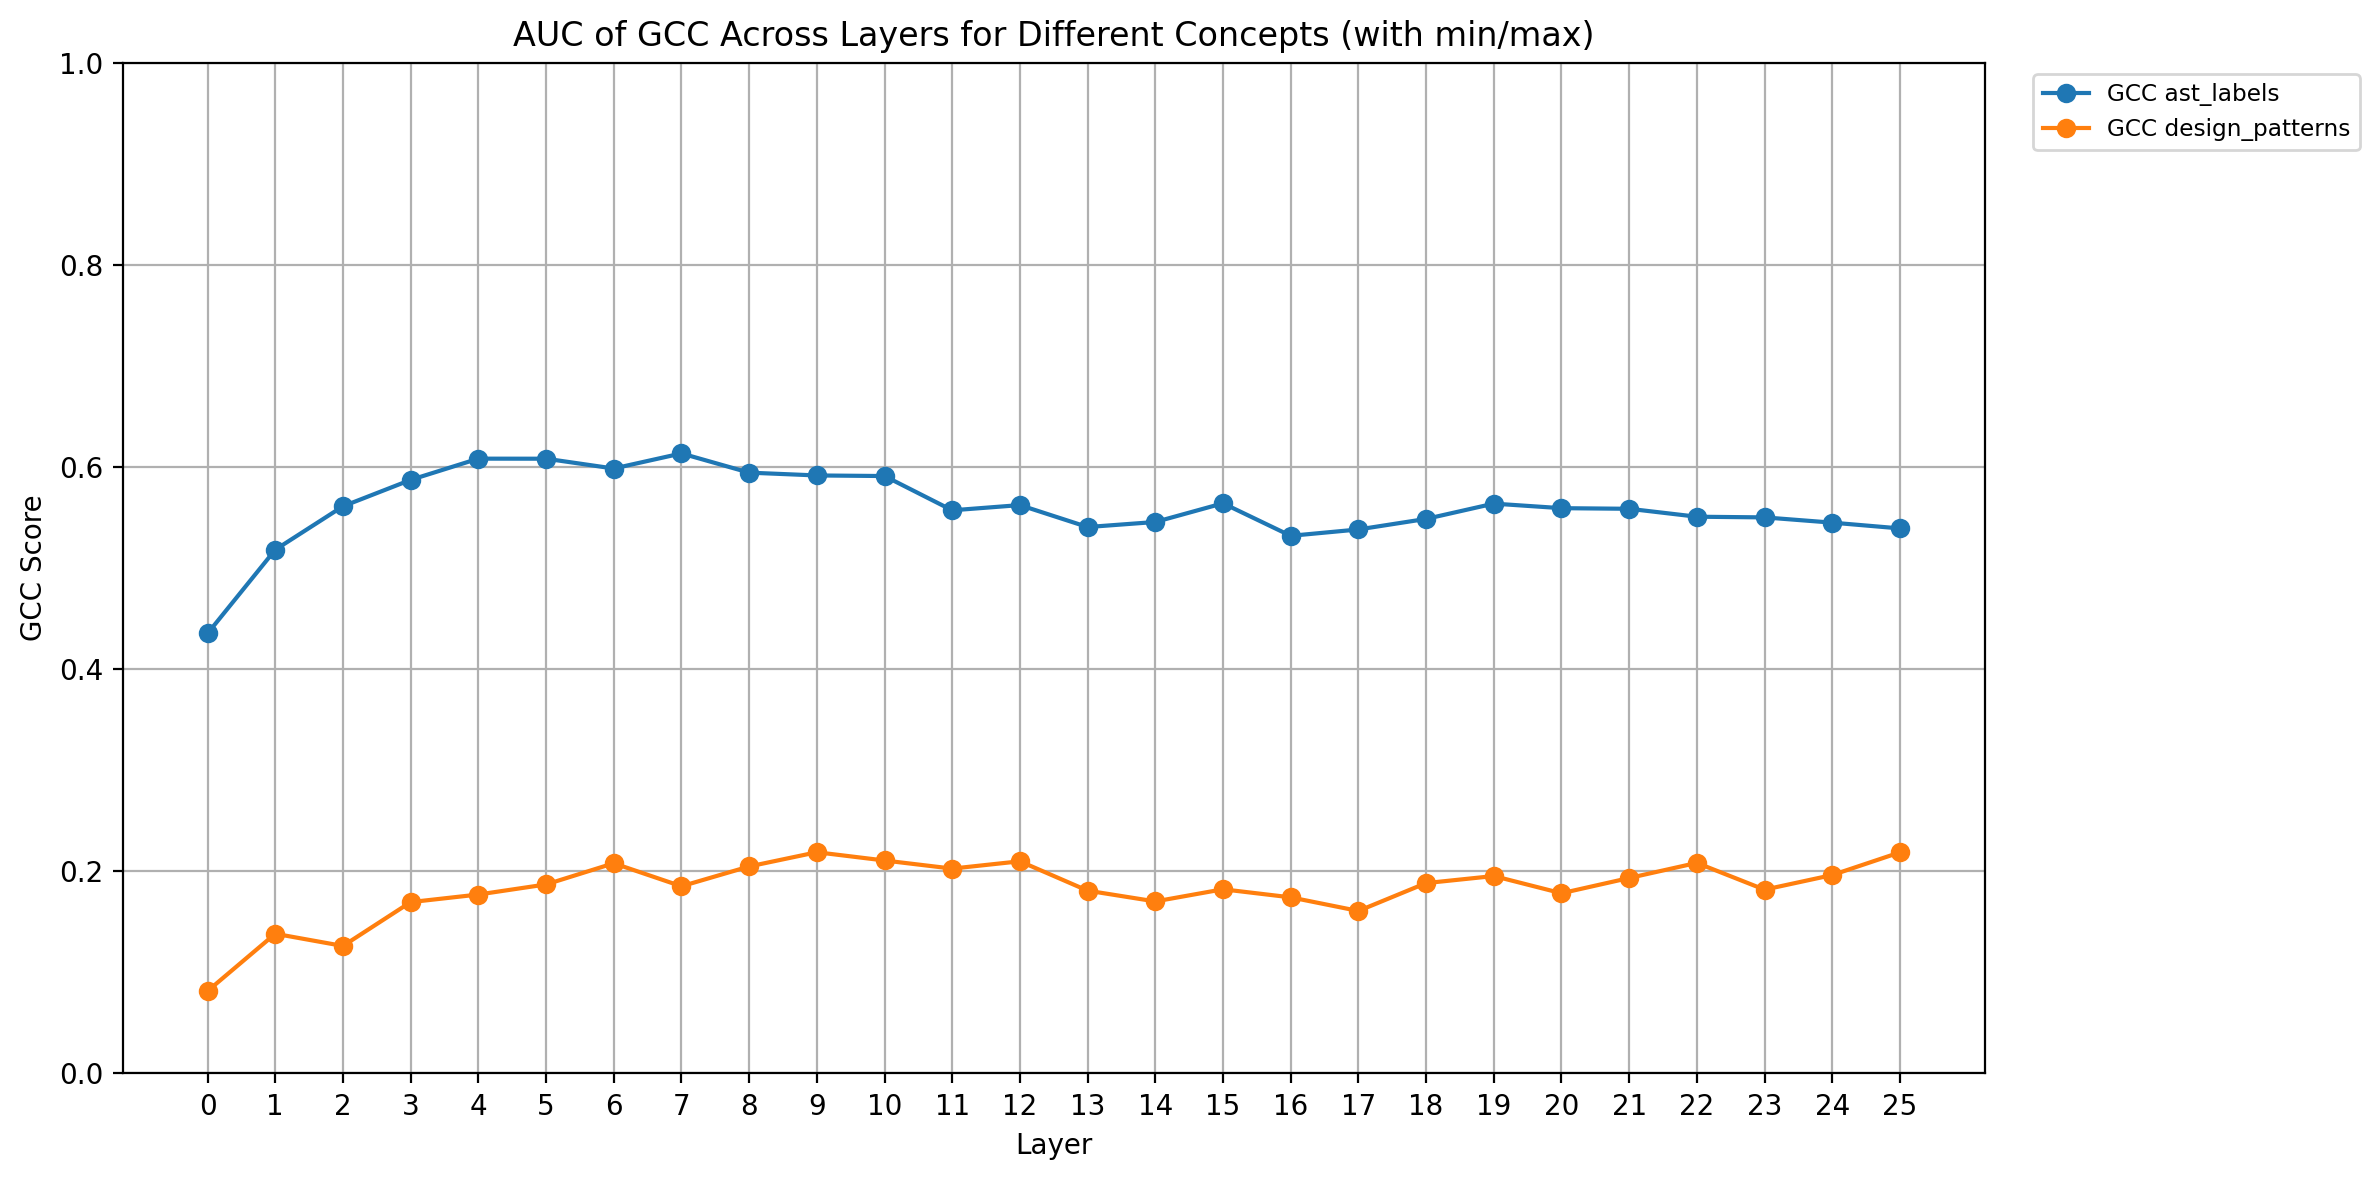

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_tcf_concept_auc(tcf_df: pd.DataFrame, n_points: int = 100) -> tuple[float, pd.DataFrame]:
    """Calcule l'AUC de la proportion de concepts couverts en fonction du seuil

    TCF.

    Args:
        tcf_df: Le DataFrame de sortie de compute_tcf_metrics contenant au moins
          les colonnes ['concept', 'tcf'].
        n_points: Le nombre de seuils à tester entre 0 et 1 (résolution de la
          courbe).

    Returns:
        auc_score: Le score AUC global (float entre 0 et 1).
        curve_df: Un DataFrame ['threshold', 'proportion_covered'] pour tracer
          la courbe.
    """
    if tcf_df.empty:
        return 0.0, pd.DataFrame(columns=["threshold", "proportion_covered"])

    # 1. Extraire le TCF maximal pour CHAQUE concept (car on veut "au moins une feature")
    max_tcf_per_concept = tcf_df.groupby("concept")["tcf"].max().values
    total_concepts = len(max_tcf_per_concept)

    # 2. Générer la grille de seuils de 0 à 1
    thresholds = np.linspace(0.0, 1.0, num=n_points)
    proportions = []

    # 3. Calculer la proportion de concepts couverts pour chaque seuil
    for tau in thresholds:
        # Nombre de concepts dont le TCF max est strictement supérieur au seuil tau
        count_above = np.sum(max_tcf_per_concept >= tau)
        proportions.append(count_above / total_concepts)

    proportions = np.array(proportions, dtype=np.float32)

    # 4. Intégration numérique via la méthode des trapèzes (np.trapezoid)
    # Comme les seuils sont linéairement espacés, dx est constant
    auc_score = float(np.trapezoid(proportions, thresholds))

    # Construction du DataFrame de tracking pour le plot
    curve_df = pd.DataFrame({
        "threshold": thresholds,
        "proportion_covered": proportions
    })

    return auc_score, curve_df

auc_scores = {}
for concept in concepts:
    auc_scores[concept] = []
    for layer in tqdm(range(26), desc=f"Computing TCF-AUC scores for {concept}"):
        tcf_df = dict_df_tcf[concept][layer]
        # Calcul de l'AUC globale de recouvrement sémantique
        auc_score, curve_data = compute_tcf_concept_auc(tcf_df, n_points=200)
        auc_scores[concept].append(auc_score)
    # check_tau = 1
    # count_above_075 = prop = curve_data.loc[np.isclose(curve_data["threshold"], check_tau, atol=0.01), "proportion_covered"].values[0]
    # print(f"Layer {layer}: AUC={auc_score:.4f}, points above 0.75: {count_above_075}")

# Plotting the AUC scores for each concept across layers with min/max lines
y_min, y_max = 0, 1
plt.figure(figsize=(12, 6), dpi=200)
for concept in concepts:
    vals = np.array(auc_scores[concept])
    ln, = plt.plot(range(26), vals, marker='o', label=f"GCC {concept}")
    # color = ln.get_color()
    # vmin, vmax = vals.min(), vals.max()
    # plt.hlines(vmin, 0, 25, colors=color, linestyles='--', linewidth=1, label=f"{concept} min")
    # plt.hlines(vmax, 0, 25, colors=color, linestyles='-.', linewidth=1, label=f"{concept} max")

plt.title("AUC of GCC Across Layers for Different Concepts (with min/max)")
plt.xlabel("Layer")
plt.ylabel("GCC Score")
plt.xticks(range(26))
plt.ylim(y_min, y_max)
plt.grid()
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()


In [103]:
dict_df_tcf['design_patterns'][12].groupby('concept').agg({'tcf': 'max'}).sort_values(by='tcf', ascending=False).head(10)

,tcf
concept,
Active object,0.491228
Builder,0.409394
Prototype,0.387097
Wrapper,0.363636
Dependency injection,0.360680
Observer,0.343520
Mixin,0.333333
Thread pool,0.333333
Assembly-level configuration (Metadata),0.333333


In [32]:
for concept in dict_df_tcf['design_patterns'][0]['concept'].unique():
    print(concept)

Abstract factory
Active object
Adapter
Assembly-level configuration (Metadata)
Bridge
Builder
Chain of responsibility
Command
Composite
Decorator
Delegation
Dependency injection
Extension object
Facade
Factory method
Flyweight
Future or promise
Interpreter
Iterator
Lazy initialization
Mediator
Memento
Mixin
Module
Multiton
Null object
Object pool
Observer
Producer-consumer
Prototype
Proxy
Reactor
Singleton
Specification
State
Strategy
Template method
Thread pool
Visitor
Wrapper


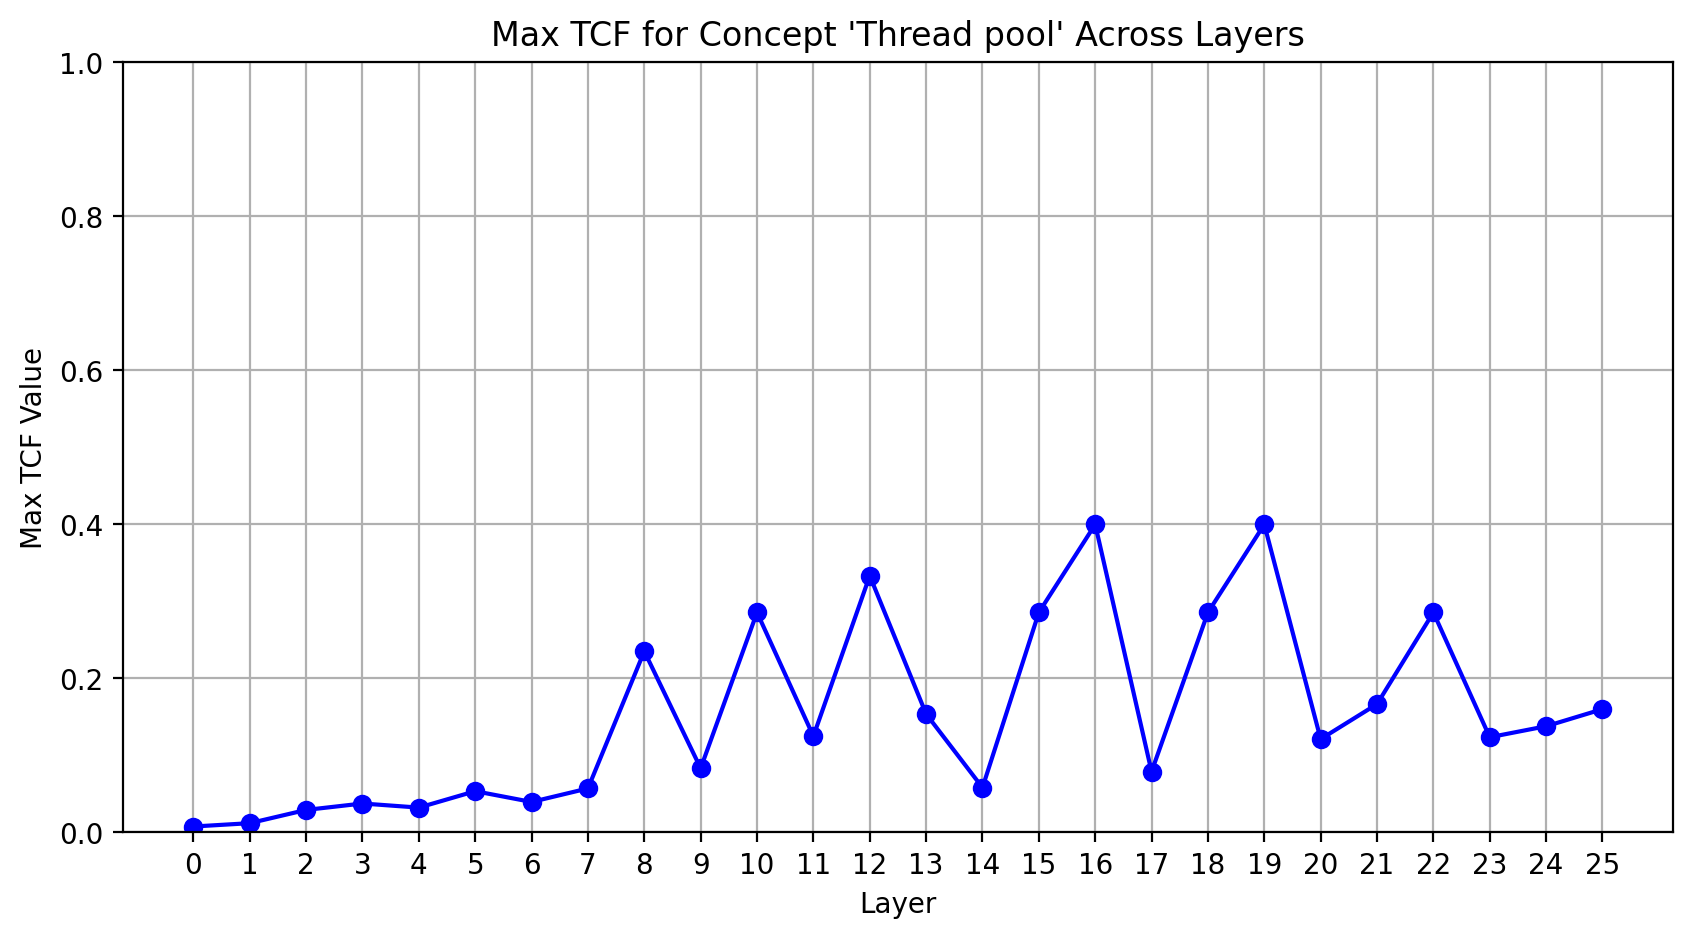

In [38]:
# plot max tcf for a designated concept across layers
category = "design_patterns"
concept = "Thread pool"
max_tcf_values = []
for layer in range(26):
    tcf_df = dict_df_tcf[category][layer]
    max_tcf_values.append(tcf_df[tcf_df['concept'] == concept]['tcf'].max())

plt.figure(figsize=(10, 5), dpi=200)
plt.plot(range(26), max_tcf_values, marker='o', label=f"Max TCF for '{concept}'", color='blue')
plt.title(f"Max TCF for Concept '{concept}' Across Layers")
plt.xlabel("Layer")
plt.ylabel("Max TCF Value")
plt.xticks(range(26))
plt.ylim(0, 1)
plt.grid()

In [112]:
df_tcf = dict_df_tcf['ast_labels'][12]

In [117]:
df_tcf[df_tcf['concept'].str.contains('for_')].sort_values(by='tcf', ascending=False).head(10)

,concept,feature_id,pmi,count_joint,f1,rank,tcf,precision,recall,span_recall,optimal_threshold
382111,for_in_clause,8449,7.201581,12,0.069565,1.0,1.000000,1.000000,0.117647,1.000000,16.958679
382415,for_in_statement,12183,4.050591,103,0.113938,3.0,0.518519,0.538462,0.017522,0.500000,16.025803
382467,for_in_statement,14897,3.345444,239,0.103553,6.0,0.454369,0.351351,0.016270,0.642857,20.487154
385832,for_statement,1533,3.280016,1178,0.296054,1.0,0.351779,0.322034,0.273953,0.387578,0.000000
385808,for_statement,13169,3.908819,487,0.184540,4.0,0.333703,0.497955,0.113256,0.250932,0.000000
382426,for_in_statement,12921,3.840143,269,0.139813,1.0,0.322981,0.238532,0.032541,0.500000,10.046322
382470,for_in_statement,6041,3.313053,78,0.075253,19.0,0.319527,0.212598,0.033792,0.642857,8.741518
382437,for_in_statement,3452,3.711716,59,0.077124,15.0,0.301741,0.183099,0.016270,0.857143,22.539581
382453,for_in_statement,6052,3.515637,186,0.108171,5.0,0.291859,0.246753,0.023780,0.357143,10.844145
385853,for_statement,14897,3.017916,1025,0.252556,2.0,0.283485,0.270206,0.237907,0.298137,3.151870


In [55]:
df_sae['path'].nunique()

774

In [52]:
dict_df_ast_purity[20] = ast_purity

Computing Average AST Purity scores: 100%|██████████| 26/26 [00:00<00:00, 2519.51it/s]


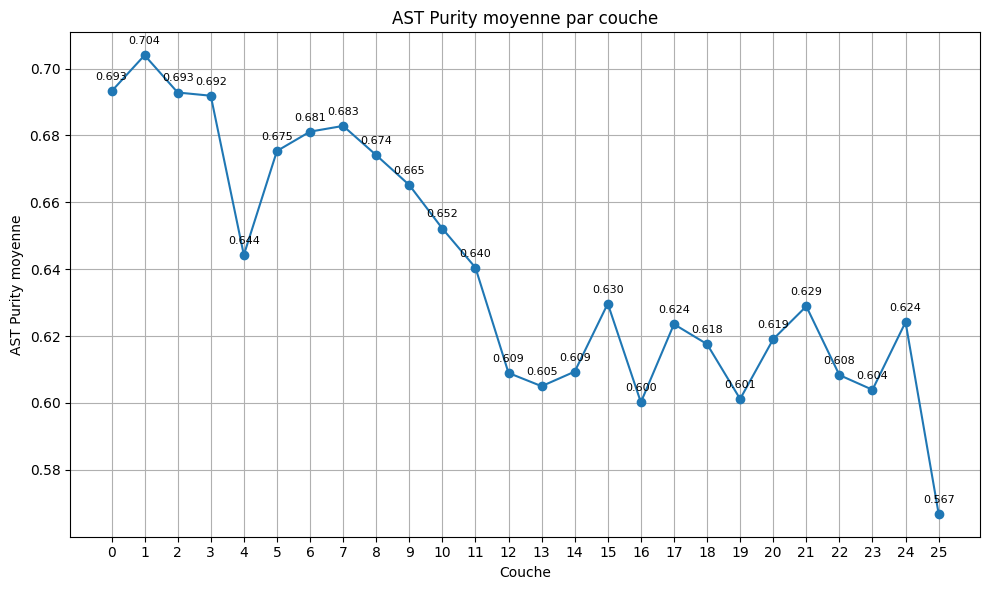

In [53]:

ast_purities = []
for layer in tqdm(range(26), desc="Computing Average AST Purity scores"):
    ast_purity_df = dict_df_ast_purity[layer]
    avg_ast_purity = ast_purity_df["ast_purity"].mean()
    ast_purities.append(avg_ast_purity)

plt.figure(figsize=(10, 6))
x = list(range(len(ast_purities)))
y = ast_purities
plt.plot(x, y, marker='o')
for xi, yi in zip(x, y):
    plt.annotate(f"{yi:.3f}", (xi, yi), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)
plt.title("AST Purity moyenne par couche")
plt.xlabel("Couche")
plt.ylabel("AST Purity moyenne")
plt.xticks(range(26))
plt.grid()
plt.tight_layout()
plt.show()